In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset/training_set.npz


In [2]:
cd /kaggle/input/dataset/

/kaggle/input/dataset


# Import libraries and dataset

In [3]:
#%pip install tensorflow==2.17 keras==3.4.1
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import os 
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
#os.environ["CUDA_VISIBLE_DEVICES"]="0"

import tensorflow as tf
import keras as tfk
import keras_cv
from keras import layers as kl
from keras_cv import layers as kcvl
from keras import mixed_precision

#mixed_precision.set_global_policy('mixed_float16')

tf.config.optimizer.set_jit(True)  # Enable XLA

print("GPUs Available: ", tf.config.list_physical_devices('GPU'))
print(f"TensorFlow version {tf.__version__}")

np.random.seed(42)
tf.random.set_seed(42)

GPUs Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version 2.16.1


In [4]:
data = np.load('training_set.npz')

X = data['images']
y = data['labels']
print(X.shape, y.shape)

(13759, 96, 96, 3) (13759, 1)


# 2 - Check for missing, duplicate values and class distribution

In [5]:
missing_targets = np.isnan(y.flatten()).any()

if not missing_targets :
    print("There are no missing or NaN values in the target vector.")

There are no missing or NaN values in the target vector.


In [6]:
# Duplicates count and removal
reshaped_X = X.reshape(X.shape[0], -1) # Reshape each image to a 1D vector and stack them for comparison

unique_X, unique_indices = np.unique(reshaped_X, axis=0, return_index=True) # Find unique images and their indices

# Select unique images and labels
X_unique = X[unique_indices]
y_unique = y[unique_indices]

print(f'Labels reduced from {len(y)} to {len(y_unique)}')

Labels reduced from 13759 to 11953


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'Basophil'),
  Text(1, 0, 'Eosinophil'),
  Text(2, 0, 'Erythroblast'),
  Text(3, 0, 'Immature granulocytes'),
  Text(4, 0, 'Lymphocyte'),
  Text(5, 0, 'Monocyte'),
  Text(6, 0, 'Neutrophil'),
  Text(7, 0, 'Platelet')])

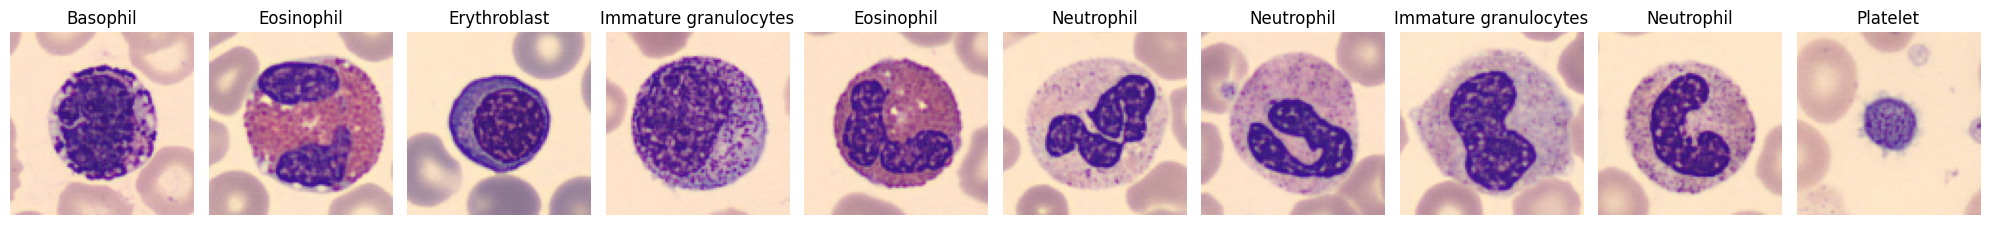

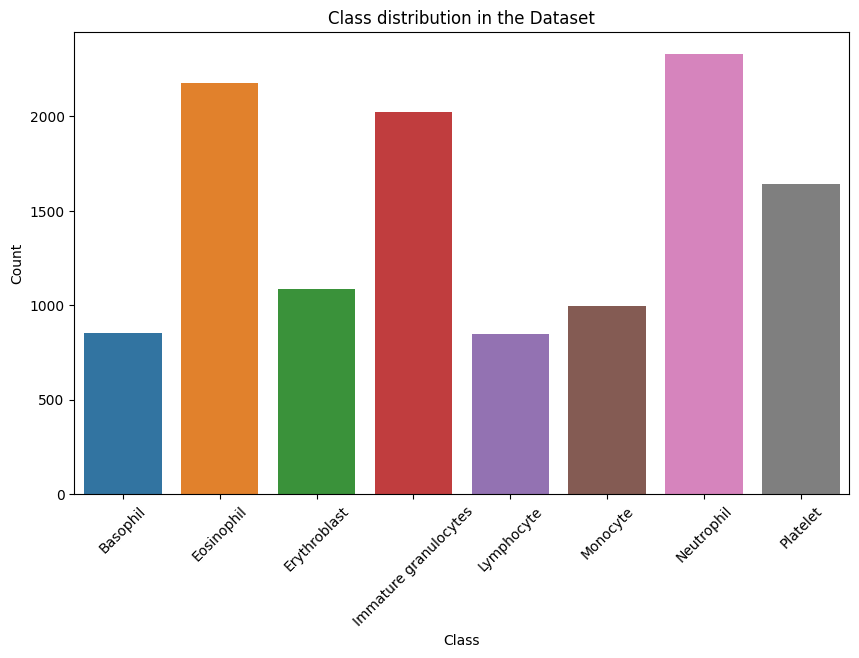

In [7]:
X = X_unique
y = y_unique

# Define a mapping of labels to their corresponding digit names
labels = {0:'Basophil', 1:'Eosinophil', 2:'Erythroblast', 3:'Immature granulocytes', 4:'Lymphocyte', 5:'Monocyte', 6:'Neutrophil', 7:'Platelet'}

# Save unique labels
unique_labels = list(labels.values())

# Display a sample of images from the training-validation dataset
num_img = 10
random_indices = random.sample(range(len(X)), num_img)

fig, axes = plt.subplots(1, num_img, figsize=(20, 20))

# Iterate through the selected number of images
for i, idx in enumerate(random_indices):
    ax = axes[i % num_img]
    ax.imshow(np.squeeze(X[idx]), vmin=0., vmax=1.)
    ax.set_title(f'{labels[y[idx][0]]}')
    ax.axis('off')

# Adjust layout and display the images
plt.tight_layout()
#plt.show()

labels_list, counts = np.unique(y.flatten(), return_counts=True)
classes = [labels[label] for label in labels_list]
df = pd.DataFrame({'Class': classes, 'Count': counts})

# Plot the barplot
plt.figure(figsize=(10, 6))
sns.barplot(x=classes, y=counts)
plt.title('Class distribution in the Dataset')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Adjust rotation for readability if needed
#plt.show()

# 3 - Split dataset into Train, Test and Validation sets while maintaining the distribution

In [8]:
from sklearn.utils.class_weight import compute_class_weight

# Split data into training, test and validation sets, maintaining class distribution
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, stratify=y_train_val)

# Print the shapes of the resulting datasets
print("Training Data Shape:", X_train.shape)
print("Training Label Shape:", y_train.shape)
print("Test Data Shape:", X_test.shape)
print("Test Label Shape:", y_test.shape)
print("Validation Data Shape:", X_val.shape)
print("Validation Label Shape:", y_val.shape)

# Convert labels to categorical format using one-hot encoding
y_train = tfk.utils.to_categorical(y_train)
y_val = tfk.utils.to_categorical(y_val)
#y_test = tfk.utils.to_categorical(y_test)

Training Data Shape: (8605, 96, 96, 3)
Training Label Shape: (8605, 1)
Test Data Shape: (2391, 96, 96, 3)
Test Label Shape: (2391, 1)
Validation Data Shape: (957, 96, 96, 3)
Validation Label Shape: (957, 1)


# 4 - Image Augmentation

In [9]:
value_range=(0, 255)
num_augmentations = 4

# Define the augmentation pipeline
layers = [
    kcvl.RandAugment(value_range=value_range, magnitude=0.1, magnitude_stddev=0.2),
    #kcvl.RandomHue(factor=0.2, value_range=value_range),  # First augmentation layer
    #kcvl.ChannelShuffle(groups=3)
    #kcvl.GridMask(),            
    #kcvl.RandomSaturation(factor=0),   
    #kcvl.AutoContrast(value_range=value_range),
    #kcvl.RandomCutout(width_factor=0.2, height_factor=0.2), 
    #kcvl.RandomSharpness(factor=0.3, value_range=value_range), 
    #kcvl.RandomShear(x_factor=0.1, y_factor=0.1),
    #kcvl.JitteredResize(target_size=(96, 96), scale_factor=(0.8, 1.2)),
    #kcvl.Solarization(threshold_factor=0.5, value_range=value_range),
    kcvl.GridMask(),            
    kcvl.RandomHue(factor=0.2, value_range=value_range),          
    kcvl.RandomSaturation(factor=0.5),   
    #kcvl.AugMix(value_range=value_range, severity=0.1),
    kcvl.RandomColorDegeneration(factor=1.0),
]

cut_mix = kcvl.CutMix(alpha=0.01)
mix_up = kcvl.MixUp()

pipeline = kcvl.RandomAugmentationPipeline(
        layers=layers,
        augmentations_per_image=num_augmentations
    )


def cut_mix_and_mix_up(samples):
    # Uncommenting these lines, plotting will we incoherent for some reason
    # samples = cut_mix(samples, training=True)
    #samples = mix_up(samples, training=True)
    return samples

def apply_pipeline(inputs):
    inputs["images"] = pipeline(inputs["images"])  # Apply RandomAugmentationPipeline
    inputs = cut_mix_and_mix_up(inputs)  # Apply CutMix and MixUp
    return inputs

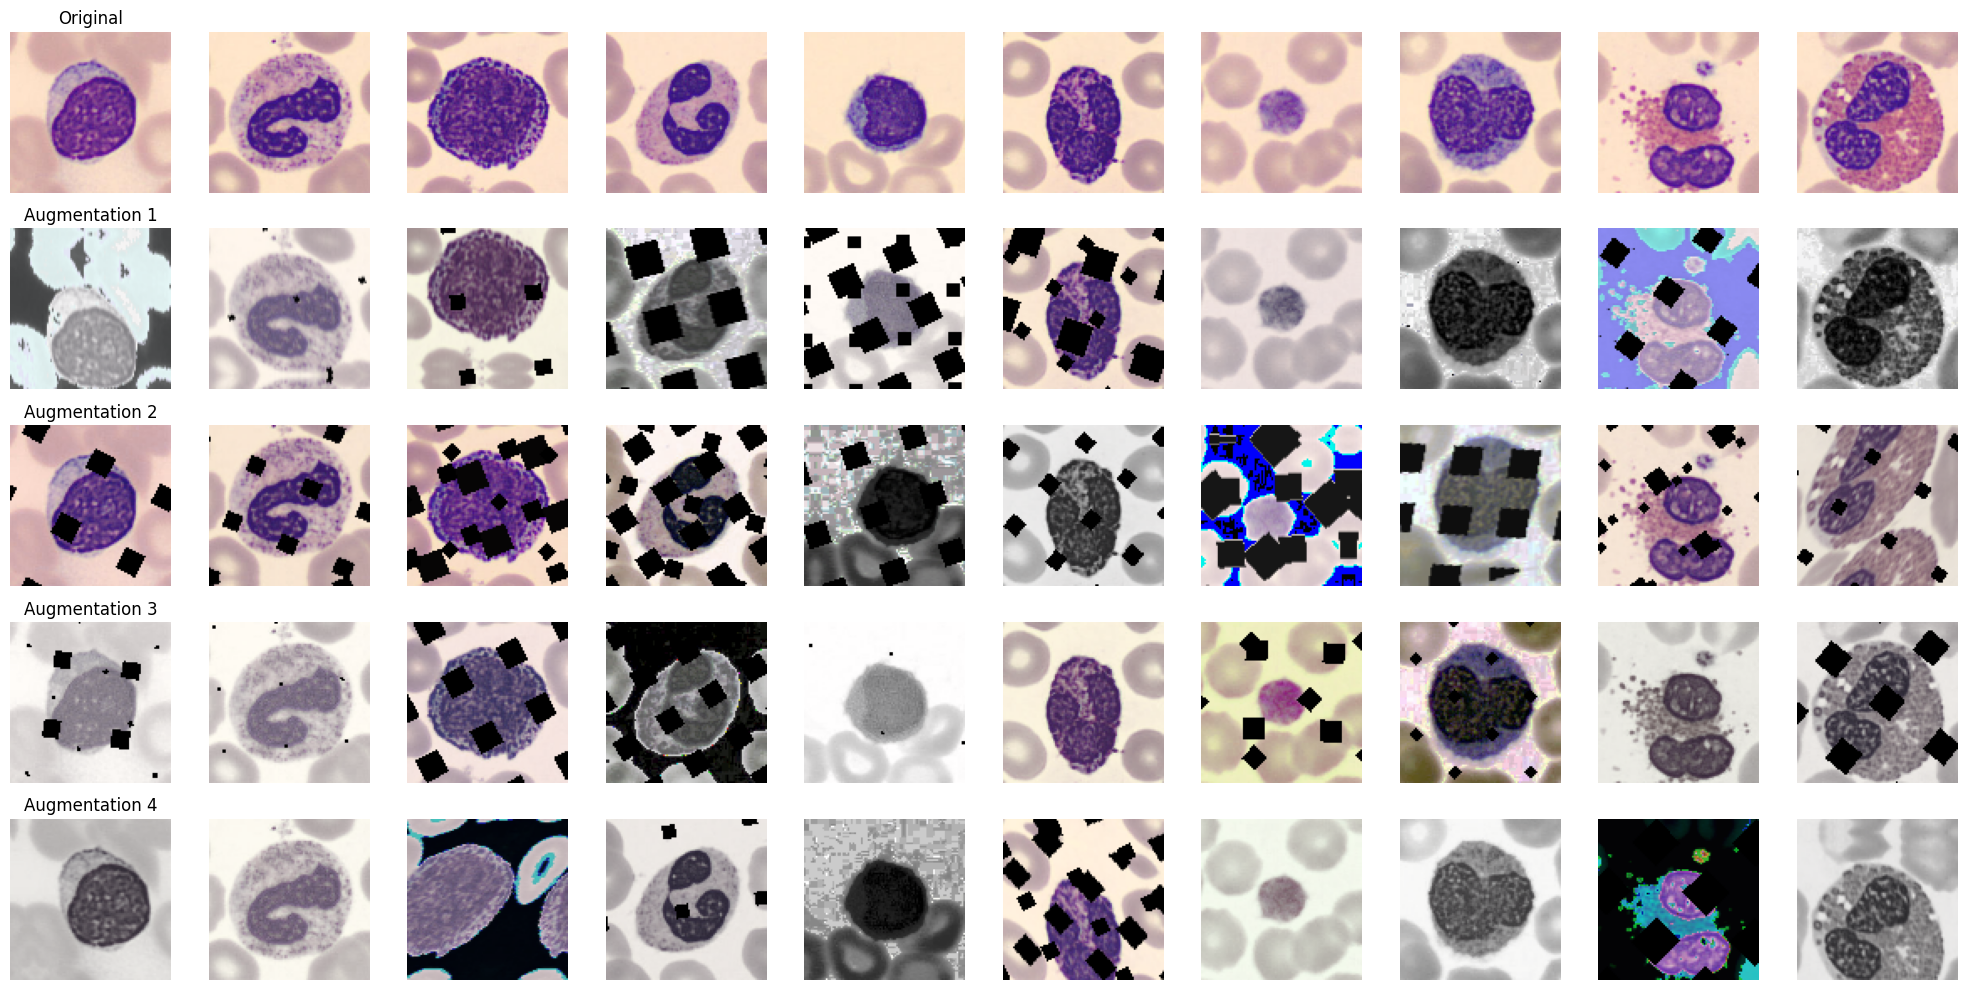

In [10]:
def plot_augmented_images(X_train, y_train, num_images, num_augmentations):
    batch = X_train[:num_images]  # Take a batch of images for visualization
    labels_batch = y_train[:num_images]
    
    fig, axes = plt.subplots(num_augmentations + 1, num_images, figsize=(20, 10))  # 4 rows, 10 columns

    # Display original images in the first row
    for i in range(num_images):
        original_image = batch[i].astype("uint8")  # Convert to uint8 for display
        axes[0, i].imshow(original_image)
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original", fontsize=12)
        else:
            axes[0, i].set_title("")

    # Display augmentations in subsequent rows
    for j in range(num_augmentations):
        augmented_batch = apply_pipeline({
            "images": tf.convert_to_tensor(batch), 
            "labels": tf.convert_to_tensor(labels_batch, dtype=tf.float32)
        })
        for i in range(num_images):
            augmented_image = tf.clip_by_value(augmented_batch["images"][i], 0, 255)  # Ensure values are in display range
            axes[j + 1, i].imshow(augmented_image.numpy().astype("uint8"))
            axes[j + 1, i].axis("off")
            if i == 0:
                axes[j + 1, i].set_title(f"Augmentation {j + 1}", fontsize=12)
            else:
                axes[j + 1, i].set_title("")

    plt.tight_layout()
    plt.show()

# Plot 10 images with 4 augmented versions each
plot_augmented_images(X_train, y_train, 10, num_augmentations)

In [11]:
batch_size = 32

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .batch(batch_size)
    .map(lambda x, y: (apply_pipeline({"images": x, "labels": tf.cast(y, tf.float32)})["images"], y), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: (x / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE)  # Normalize images to [0, 1]
    .prefetch(tf.data.AUTOTUNE)
)

# Apply normalization to val_dataset
val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(batch_size)
    .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE)  # Normalize images to [0, 1]
    .prefetch(tf.data.AUTOTUNE)
)

# 5 - Build and Train the model

In [12]:
input_shape = X_train.shape[1:]
output_shape = y_train.shape[1]

# Example of filter and stack configuration for each block
block_config = [
    {"filters": 16, "stack": 1, "downsample": False},  # Initial layer
    {"filters": 24, "stack": 2, "downsample": True},   # Second layer, downsamples
    {"filters": 40, "stack": 2, "downsample": True},   # Third layer, downsamples
    {"filters": 80, "stack": 3, "downsample": True},   # Fourth layer, downsamples
    {"filters": 112, "stack": 3, "downsample": False}, # Fifth layer
    {"filters": 160, "stack": 3, "downsample": True},  # Final layer, downsamples
]

print("Input Shape:", input_shape)
print("Output Shape:", output_shape)

Input Shape: (96, 96, 3)
Output Shape: 8


In [13]:
from keras import layers as tfkl

# Define the MobileNetV3 block with configurable parameters
def mobilenetv3_block(x, filters, kernel_size=3, padding='same',
                      downsample=True, activation='h_swish', stack=1, name='mobilev3'):

    # Define h-swish activation function
    def h_swish(x):
        return x * tf.nn.relu6(x + 3.0) / 6.0

    # Select activation function
    activation_fn = tf.nn.relu if activation == 'relu' else h_swish

    for s in range(stack):
        input_channels = x.shape[-1]
        residual = x

        # Set expansion factor based on channel dimensions
        expansion_factor = 1 if input_channels == filters else 6
        expanded_channels = input_channels * expansion_factor

        # Expansion phase
        if expansion_factor != 1:
            x = tfkl.Conv2D(expanded_channels, 1, padding=padding, use_bias=False, name=f'{name}_expand_{s}')(x)
            x = tfkl.BatchNormalization(name=f'{name}_bn1_{s}')(x)
            x = tfkl.Activation(activation_fn, name=f'{name}_act1_{s}')(x)

        # Depthwise convolution with optional downsampling
        stride = 2 if (downsample and s == 0) else 1
        x = tfkl.DepthwiseConv2D(kernel_size, strides=stride, padding=padding, use_bias=False, name=f'{name}_depthwise_{s}')(x)
        x = tfkl.BatchNormalization(name=f'{name}_bn2_{s}')(x)
        x = tfkl.Activation(activation_fn, name=f'{name}_act2_{s}')(x)

        # Squeeze-and-Excitation module
        se_channels = max(1, expanded_channels // 4)
        se = tfkl.GlobalAveragePooling2D(name=f'{name}_se_pool_{s}')(x)
        se = tfkl.Reshape((1, 1, expanded_channels))(se)
        se = tfkl.Conv2D(se_channels, 1, activation='relu', name=f'{name}_se_reduce_{s}')(se)
        se = tfkl.Conv2D(expanded_channels, 1, activation='hard_sigmoid', name=f'{name}_se_expand_{s}')(se)
        x = tfkl.Multiply(name=f'{name}_se_excite_{s}')([x, se])

        # Projection phase to desired filter dimension
        x = tfkl.Conv2D(filters, 1, padding=padding, use_bias=False, name=f'{name}_project_{s}')(x)
        x = tfkl.BatchNormalization(name=f'{name}_bn3_{s}')(x)

        # Add skip connection if applicable
        if stride == 1 and input_channels == filters:
            x = tfkl.Add(name=f'{name}_add_{s}')([residual, x])

    return x

# Define the input layer and apply MobileNetV3 block
input_layer = tfkl.Input(shape=input_shape, name='input_layer')
#x = mobilenetv3_block(x=input_layer, filters=filters, kernel_size=kernel_size, downsample=False, name='block0', stack=stack)
x = input_layer

# Loop through each block configuration to build the model
for i, config in enumerate(block_config):
    x = mobilenetv3_block(
        x=x, 
        filters=config["filters"], 
        kernel_size=3,  # Choose 3 or 5 based on your preference
        downsample=config["downsample"], 
        stack=config["stack"], 
        name=f'block_{i}'
    )

# Global Average Pooling and fully connected output layer
x = tfkl.GlobalAveragePooling2D(name='gap')(x)
x = tfkl.Dense(output_shape, name='dense')(x)
x = tfkl.Activation('softmax', name='softmax')(x)

# Compile the model
model = tfk.Model(inputs=input_layer, outputs=x, name='architecture')
model.compile(loss=tfk.losses.CategoricalCrossentropy(), optimizer=tf.keras.optimizers.Lion(), metrics=['accuracy'])

# Display model summary and plot
model.summary(expand_nested=True, show_trainable=True)
#tfk.utils.plot_model(model, expand_nested=True, show_trainable=True, show_shapes=True, dpi=70)

Model: "architecture"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer       │ (None, 96, 96,  │         0 │ -              │   -   │
│ (InputLayer)      │ 3)              │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_expand_0  │ (None, 96, 96,  │        54 │ input_layer[0… │   Y   │
│ (Conv2D)          │ 18)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_bn1_0     │ (None, 96, 96,  │        72 │ block_0_expan… │   Y   │
│ (BatchNormalizat… │ 18)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_act1_0    │ (None, 96, 96,  │         0 │ block_0_bn1_0… │   -   │
│ (Activation)      │ 18)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_depthwis… │ (None, 96, 96,  │       162 │ block_0_act1_… │   Y   │
│ (DepthwiseConv2D) │ 18)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_bn2_0     │ (None, 96, 96,  │        72 │ block_0_depth… │   Y   │
│ (BatchNormalizat… │ 18)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_act2_0    │ (None, 96, 96,  │         0 │ block_0_bn2_0… │   -   │
│ (Activation)      │ 18)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_se_pool_0 │ (None, 18)      │         0 │ block_0_act2_… │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ reshape (Reshape) │ (None, 1, 1,    │         0 │ block_0_se_po… │   -   │
│                   │ 18)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_se_reduc… │ (None, 1, 1, 4) │        76 │ reshape[0][0]  │   Y   │
│ (Conv2D)          │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_se_expan… │ (None, 1, 1,    │        90 │ block_0_se_re… │   Y   │
│ (Conv2D)          │ 18)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_se_excit… │ (None, 96, 96,  │         0 │ block_0_act2_… │   -   │
│ (Multiply)        │ 18)             │           │ block_0_se_ex… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_project_0 │ (None, 96, 96,  │       288 │ block_0_se_ex… │   Y   │
│ (Conv2D)          │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_bn3_0     │ (None, 96, 96,  │        64 │ block_0_proje… │   Y   │
│ (BatchNormalizat… │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_0  │ (None, 96, 96,  │     1,536 │ block_0_bn3_0… │   Y   │
│ (Conv2D)          │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_bn1_0     │ (None, 96, 96,  │       384 │ block_1_expan… │   Y   │
│ (BatchNormalizat… │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_act1_0    │ (None, 96, 96,  │         0 │ block_1_bn1_0… │   - 

 Total params: 886,094 (3.38 MB)

 Trainable params: 875,558 (3.34 MB)

 Non-trainable params: 10,536 (41.16 KB)

In [14]:
mixed_precision.set_global_policy('mixed_float16')

In [15]:
epochs = 10000

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    train_dataset,
    #X_train, y_train,
    validation_data=val_dataset,
    #validation_data=(X_val, y_val),
    epochs=epochs,
    callbacks=[early_stopping, reduce_lr],
    #class_weight=adjusted_class_weights
).history

# Calculate and print the final validation accuracy
#final_val_accuracy = round(max(history['val_accuracy'])* 100, 2)

# Save the trained model to a file with the accuracy included in the filename
model_filename = '/kaggle/working/CNN'+'.keras'
model.save(model_filename)

# Delete the model to free up resources
del model

Epoch 1/10000


I0000 00:00:1731590080.293687      97 service.cc:145] XLA service 0x5d1d6187ee90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731590080.293757      97 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1731590080.382677      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


269/269 ━━━━━━━━━━━━━━━━━━━━ 158s 417ms/step - accuracy: 0.3193 - loss: 1.9220 - val_accuracy: 0.0711 - val_loss: 125.5771 - learning_rate: 0.0010
Epoch 2/10000
269/269 ━━━━━━━━━━━━━━━━━━━━ 98s 333ms/step - accuracy: 0.6277 - loss: 0.9952 - val_accuracy: 0.4169 - val_loss: 10.1437 - learning_rate: 0.0010
Epoch 3/10000
269/269 ━━━━━━━━━━━━━━━━━━━━ 98s 335ms/step - accuracy: 0.7222 - loss: 0.7893 - val_accuracy: 0.5914 - val_loss: 1.8581 - learning_rate: 0.0010
Epoch 4/10000
269/269 ━━━━━━━━━━━━━━━━━━━━ 98s 333ms/step - accuracy: 0.7626 - loss: 0.6795 - val_accuracy: 0.7231 - val_loss: 0.7978 - learning_rate: 0.0010
Epoch 5/10000
269/269 ━━━━━━━━━━━━━━━━━━━━ 99s 335ms/step - accuracy: 0.7854 - loss: 0.5993 - val_accuracy: 0.8558 - val_loss: 0.4453 - learning_rate: 0.0010
Epoch 6/10000
269/269 ━━━━━━━━━━━━━━━━━━━━ 99s 335ms/step - accuracy: 0.8041 - loss: 0.5349 - val_accuracy: 0.8652 - val_loss: 0.4271 - learning_rate: 0.0010
Epoch 7/10000
269/269 ━━━━━━━━━━━━━━━━━━━━ 101s 343ms/step - a

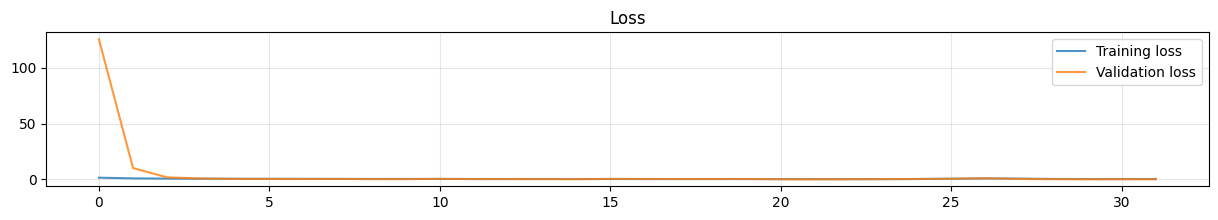

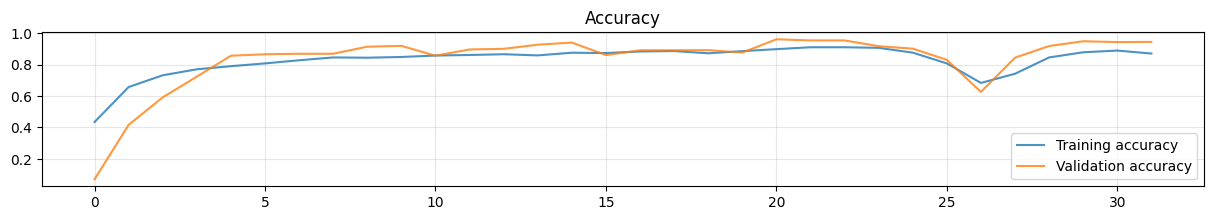

In [16]:
# Plot training and validation loss
plt.figure(figsize=(15, 2))
plt.plot(history['loss'], label='Training loss', alpha=.8)
plt.plot(history['val_loss'], label='Validation loss', alpha=.8)
plt.title('Loss')
plt.legend()
plt.grid(alpha=.3)

# Plot training and validation accuracy
plt.figure(figsize=(15, 2))
plt.plot(history['accuracy'], label='Training accuracy', alpha=.8)
plt.plot(history['val_accuracy'], label='Validation accuracy', alpha=.8)
plt.title('Accuracy')
plt.legend()
plt.grid(alpha=.3)
plt.show()

# 6 - Evaluate the model

In [17]:
cd /kaggle/working

/kaggle/working


In [33]:
# Define h-swish activation function
def h_swish(x):
    return x * tf.nn.relu6(x + 3.0) / 6.0

# Load the saved model
model = tf.keras.models.load_model(model_filename, custom_objects={'h_swish': h_swish})

In [ ]:
X

In [39]:
# Preprocess competition data
true_classes = y_test.flatten()
X_test = X_test / 255.0

In [40]:
# Predict labels for the entire test set
predictions = model.predict(X_test, verbose=0)

# Display the shape of the predictions
print("Predictions Shape:", predictions.shape)

Predictions Shape: (2391, 8)


In [41]:
predictions

array([[8.6118774e-03, 9.4712141e-06, 2.4032590e-03, ..., 1.2258805e-06,
        1.4385759e-06, 1.0062814e-05],
       [4.3664863e-07, 4.7140336e-08, 9.9994981e-01, ..., 2.7793956e-11,
        5.1585062e-08, 2.8420638e-07],
       [9.1419412e-07, 3.1671894e-07, 9.9776220e-01, ..., 1.0043492e-08,
        5.2650013e-09, 3.1872771e-06],
       ...,
       [6.7705892e-05, 1.6745249e-05, 2.4582429e-08, ..., 9.9961156e-01,
        6.6632500e-05, 1.0813324e-08],
       [1.9779756e-09, 2.4821611e-07, 2.7232807e-05, ..., 2.2170676e-08,
        1.2369301e-07, 9.9997056e-01],
       [3.2861955e-08, 2.7299421e-09, 1.8874402e-04, ..., 4.0349550e-09,
        4.6519641e-08, 9.9981040e-01]], dtype=float32)

In [44]:
pred_classes

array([4, 2, 2, ..., 5, 7, 7])

Accuracy score over the test set: 0.9519
Precision score over the test set: 0.9531
Recall score over the test set: 0.9519
F1 score over the test set: 0.9518


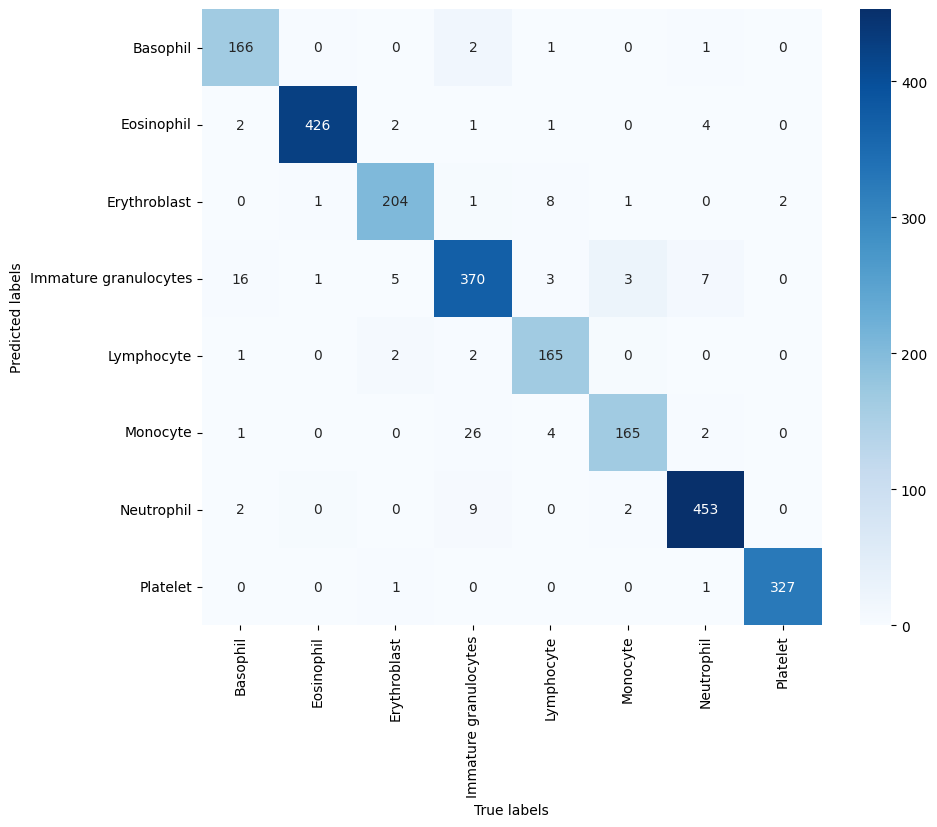

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

pred_classes = np.argmax(predictions, axis=-1)

# Calculate and display test set accuracy
accuracy = accuracy_score(true_classes, pred_classes)
print(f'Accuracy score over the test set: {round(accuracy, 4)}')

# Calculate and display test set precision
precision = precision_score(true_classes, pred_classes, average='weighted')
print(f'Precision score over the test set: {round(precision, 4)}')

# Calculate and display test set recall
recall = recall_score(true_classes, pred_classes, average='weighted')
print(f'Recall score over the test set: {round(recall, 4)}')

# Calculate and display test set F1 score
f1 = f1_score(true_classes, pred_classes, average='weighted')
print(f'F1 score over the test set: {round(f1, 4)}')

# Compute the confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

# Combine numbers and percentages into a single string for annotation
annot = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm.T, annot=annot, fmt='', xticklabels=list(labels.values()), yticklabels=list(labels.values()), cmap='Blues')
plt.xlabel('True labels')
plt.ylabel('Predicted labels')
plt.show()